# 02 Data Understanding

In CRISP-DM Phase 2 beginnen wir mit der Datenverständ­nissanalyse. Dieser erste Abschnitt lädt den BRFSS-Datensatz aus dem UCI-Repository und prüft die grundlegende Struktur für die weitere EDA.

## 1. Setup
Installiere den UCI-ML-Repository-Client, falls er noch nicht verfügbar ist, und importiere anschließend alle benötigten Bibliotheken.

In [9]:
# Install ucimlrepo if running in a fresh environment
import importlib, subprocess, sys
if importlib.util.find_spec('ucimlrepo') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo'])


import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
from ucimlrepo import fetch_ucirepo

## 1. Datensatz laden 

Wir laden den Datensatz direkt aus dem UCI ML Repository über seine offizielle ID (891). Dadurch ist die Reproduzierbarkeit gewährleistet, ohne dass eine lokale CSV-Datei benötigt wird.

In [10]:
# Fetch dataset from UCI ML Repository
dataset = fetch_ucirepo(id=891)

X = dataset.data.features
y = dataset.data.targets

# Combine into a single DataFrame for convenience
df = pd.concat([X, y], axis=1)

print(f'Dataset loaded: {df.shape[0]:,}  × {df.shape[1]}')

Dataset loaded: 253,680  × 22


## 2. Grundstruktur

Bevor wir inhaltlich analysieren, verschaffen wir uns einen Überblick über Dimensionen, Datentypen und fehlende Werte — die drei grundlegendsten Qualitätsfragen bei jedem neuen Datensatz.

In [11]:
# --- Dimensionen ---
n_rows, n_cols = df.shape
print(f"Zeilen : {n_rows:,}")
print(f"Spalten: {n_cols}  (21 Features + 1 Target)\n")

# --- Features & Datentypen ---
dtype_map = df.dtypes.rename("dtype")
missing   = df.isnull().sum().rename("missing")
missing_pct = (missing / n_rows * 100).round(4).rename("missing_%")

summary = pd.concat([dtype_map, missing, missing_pct], axis=1)
print(summary.to_string())
print(f"\nGesamte fehlende Werte: {missing.sum()}")

Zeilen : 253,680
Spalten: 22  (21 Features + 1 Target)

                      dtype  missing  missing_%
HighBP                int64        0        0.0
HighChol              int64        0        0.0
CholCheck             int64        0        0.0
BMI                   int64        0        0.0
Smoker                int64        0        0.0
Stroke                int64        0        0.0
HeartDiseaseorAttack  int64        0        0.0
PhysActivity          int64        0        0.0
Fruits                int64        0        0.0
Veggies               int64        0        0.0
HvyAlcoholConsump     int64        0        0.0
AnyHealthcare         int64        0        0.0
NoDocbcCost           int64        0        0.0
GenHlth               int64        0        0.0
MentHlth              int64        0        0.0
PhysHlth              int64        0        0.0
DiffWalk              int64        0        0.0
Sex                   int64        0        0.0
Age                   int64     

## 3. Semantische Variablentypen

Nachdem die technische Grundstruktur des Datensatzes geprüft wurde, werden nun die inhaltlichen Variablentypen untersucht. Zwar sind alle Spalten als `int64` gespeichert, daraus lässt sich aber noch nicht ableiten, ob eine Variable tatsächlich numerisch, binär oder kategorial zu interpretieren ist.

Deshalb wird für jede Variable betrachtet, wie viele unterschiedliche Werte vorkommen und welche Wertebereiche vorliegen. Auf dieser Grundlage können die Merkmale anschließend sinnvoll in binäre Indikatoren, ordinale Kategorien und numerische beziehungsweise zählartige Variablen eingeordnet werden.

In [18]:
# All columns including the target variable
rows = []
for col in df.columns:
    n_unique = df[col].nunique()
    vals = sorted(df[col].unique().tolist())
    rows.append({
        "Variable":     col,
        "Rolle":        "Target" if col == "Diabetes_binary" else "Feature",
        "n_unique":     n_unique,
        "min":          df[col].min(),
        "max":          df[col].max(),
        "Ausprägungen": str(vals) if n_unique <= 15 else f"{vals[:5]} … {vals[-1]}",
    })

type_df = pd.DataFrame(rows).sort_values("n_unique")
print(type_df.to_string(index=False))

            Variable   Rolle  n_unique  min  max                                Ausprägungen
              HighBP Feature         2    0    1                                      [0, 1]
            HighChol Feature         2    0    1                                      [0, 1]
           CholCheck Feature         2    0    1                                      [0, 1]
              Smoker Feature         2    0    1                                      [0, 1]
HeartDiseaseorAttack Feature         2    0    1                                      [0, 1]
              Stroke Feature         2    0    1                                      [0, 1]
        PhysActivity Feature         2    0    1                                      [0, 1]
              Fruits Feature         2    0    1                                      [0, 1]
         NoDocbcCost Feature         2    0    1                                      [0, 1]
             Veggies Feature         2    0    1                      

Die Übersicht zeigt, dass die meisten Variablen binär kodiert sind. `HighBP`, `HighChol`, `CholCheck`, `Smoker`, `HeartDiseaseorAttack`, `Stroke`, `PhysActivity`, `Fruits`, `NoDocbcCost`, `Veggies`, `HvyAlcoholConsump`, `AnyHealthcare`, `Sex` und `DiffWalk` haben jeweils genau zwei Ausprägungen: 0 und 1. Sie zeigen an, ob ein bestimmtes Merkmal, Verhalten oder ein Gesundheitszustand vorliegt.

Neben diesen binären Features gibt es vier ordinal kodierte Merkmale: `GenHlth` (5 Stufen), `Education` (6 Stufen), `Income` (8 Stufen) und `Age` (13 Stufen). Die Reihenfolge der Werte trägt Informationen; die Abstände zwischen Kategorien sind nicht notwendig gleich groß.

`MentHlth` und `PhysHlth` nehmen Werte von 0 bis 30 an und bilden die Anzahl der beeinträchtigten Tage im letzten Monat ab — zählartige Merkmale mit einer Häufung bei 0. `BMI` weist mit 84 Ausprägungen und einem Bereich von 12 bis 98 die größte Spannweite auf und wird als numerisches Merkmal behandelt.

Das Target `Diabetes_binary` ist ebenfalls binär (0 = kein Diabetes, 1 = Prä-/Diabetes) mit den bereits bekannten Klassenverteilung (~86 % / ~14 %).

### 3.1 Variablenbeschreibungen

Die folgende Tabelle beschreibt die inhaltliche Bedeutung jeder Variable. Die Definitionen basieren auf den offiziellen BRFSS-2015-Fragebögen (CDC) und der UCI-Repository-Dokumentation.

| Variable | Rolle | Typ | Bedeutung |
|---|---|---|---|
| **Diabetes_binary** | **Target** | binary | 0 = kein Diabetes, 1 = Prä-/Diabetes (Ever told)  |
| HighBP | Feature | binary | 0 = kein Bluthochdruck, 1 = Bluthochdruck diagnostiziert |
| HighChol | Feature | binary | 0 = kein erhöhter Cholesterinwert, 1 = erhöhter Wert diagnostiziert |
| CholCheck | Feature | binary | 0 = kein Cholesterin-Check in den letzten 5 Jahren, 1 = Check erfolgt |
| Smoker | Feature | binary | 0 = nein, 1 = mind. 100 Zigaretten im Leben geraucht |
| Stroke | Feature | binary | 0 = kein Schlaganfall, 1 = jemals Schlaganfall gehabt (Ever told) |
| HeartDiseaseorAttack | Feature | binary | 0 = keine, 1 = koronare Herzerkrankung oder Herzinfarkt |
| PhysActivity | Feature | binary | 0 = nein, 1 = körperl. Aktivität in den letzten 30 Tagen (nicht beruflich) |
| Fruits | Feature | binary | 0 = nein, 1 = Obst ≥ 1× täglich |
| Veggies | Feature | binary | 0 = nein, 1 = Gemüse ≥ 1× täglich |
| HvyAlcoholConsump | Feature | binary | 0 = nein, 1 = starker Alkoholkonsum (Männer ≥14, Frauen ≥7 Drinks/Woche) |
| AnyHealthcare | Feature | binary | 0 = keine, 1 = irgendeine Krankenversicherung vorhanden |
| NoDocbcCost | Feature | binary | 0 = nein, 1 = Arztbesuch trotz Bedarf aus Kostengründen unterblieben |
| DiffWalk | Feature | binary | 0 = nein, 1 = erhebliche Schwierigkeiten beim Gehen oder Treppensteigen |
| Sex | Feature | binary | 0 = weiblich, 1 = männlich |
| GenHlth | Feature | ordinal | Allgemeiner Gesundheitszustand: 1 = ausgezeichnet, 2=sehr gut, 3=gut, 4= in Ordnung, 5 = schlecht |
| Age | Feature | ordinal | Alterskategorie: 1 = 18–24 J., 2 = 25–29 J., …, 13 = ≥ 80 J. (je ~5 Jahre) |
| Education | Feature | ordinal | Bildungsgrad: 1 = nie Schule/nur Kindergarten, 2 = Klassenstufen 1–8, 3 = Klassenstufen 9–11, 4 = Klassenstufe 12 oder GED/High-School-Abschluss, 5 = 1–3 Jahre College/technische Schule, 6 = 4 Jahre College oder mehr/College-Abschluss |
| Income | Feature | ordinal | Haushaltseinkommen: 1 = < $10 000 … 8 = ≥ $75 000 |
| MentHlth | Feature | count | Tage mit eingeschränkter psychischer Gesundheit in den letzten 30 Tagen (0–30) |
| PhysHlth | Feature | count | Tage mit körperlicher Erkrankung oder Verletzung in den letzten 30 Tagen (0–30) |
| BMI | Feature | numeric | Body-Mass-Index (ganzzahlig gerundet; Wertebereich 12–98) |

## 4. Verteilung der Zielvariable

Bevor wir mit der Feature-Analyse beginnen, schauen wir uns die Verteilung des Targets `Diabetes_binary` an.

=== Klassenverteilung ===
  0 – Kein Diabetes           218,334  (86.1 %)
  1 – Prä-/Diabetes            35,346  (13.9 %)

  Gesamt: 253,680


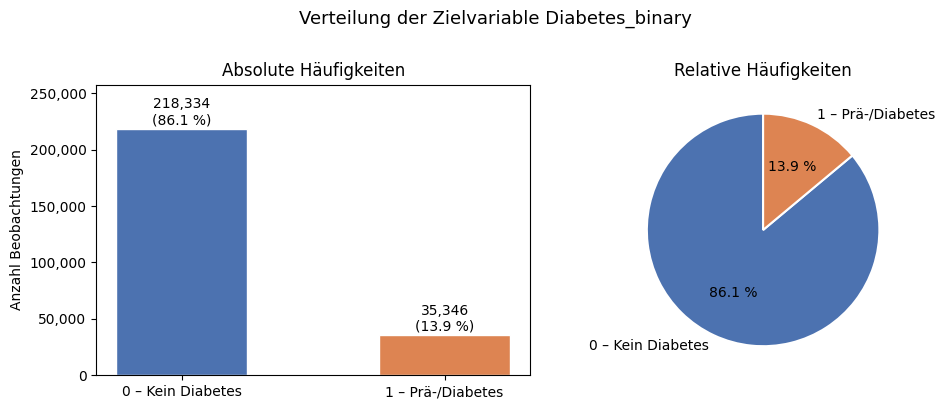

In [19]:
counts = df["Diabetes_binary"].value_counts().sort_index()
labels = ["0 – Kein Diabetes", "1 – Prä-/Diabetes"]

print("=== Klassenverteilung ===")
for n, lbl in zip(counts, labels):
    print(f"  {lbl:<26}  {n:>7,}  ({n/counts.sum()*100:.1f} %)")
print(f"\n  Gesamt: {counts.sum():,}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts.values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for i, (n, pct) in enumerate(zip(counts.values, counts.values / counts.sum() * 100)):
    axes[0].text(i, n + 1500, f"{n:,}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Absolute Häufigkeiten", fontsize=12)
axes[0].set_ylabel("Anzahl Beobachtungen")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, counts[0] * 1.18)

axes[1].pie(
    counts.values,
    labels=labels,
    autopct="%1.1f %%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Relative Häufigkeiten", fontsize=12)

plt.suptitle("Verteilung der Zielvariable Diabetes_binary", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Die Zielvariable `Diabetes_binary` ist deutlich ungleich verteilt. Von insgesamt 253.680 Beobachtungen gehören 218.334 Personen zur Klasse 0, also zur Gruppe ohne Diabetes. Das entspricht 86,1 % des Datensatzes. Die Klasse 1, also Prädiabetes/Diabetes, umfasst 35.346 Personen und macht damit nur 13,9 % der Beobachtungen aus.

Damit liegt ein deutliches Klassenungleichgewicht vor. Für die spätere Modellierung bedeutet das, dass Accuracy allein keine geeignete Hauptmetrik ist, da ein Modell bereits durch überwiegende Vorhersage der Mehrheitsklasse hohe Accuracy-Werte erreichen könnte. Für dieses Projekt sind daher Metriken wichtiger, die die Minderheitsklasse stärker berücksichtigen, insbesondere PR-AUC beziehungsweise Average Precision sowie Recall, Precision und F1-Score.

Die Klassenverteilung bestätigt außerdem, dass das Projekt als imbalanced binary classification problem behandelt werden sollte.

## 5. Duplikat- und Label-Konsistenz-Analyse

BRFSS ist eine telefonische Querschnittsbefragung — jede Person sollte genau einmal erfasst sein. Dennoch können identische Zeilen aus zwei Quellen stammen: echte Wiederholungsteilnahme (selten) oder doppelter Eintrag bei der Datenbankbereinigung. Darüber hinaus interessiert uns, ob es Feature-Vektoren gibt, die mit widersprüchlichen Labels auftauchen: gleiche Merkmalskombination, aber unterschiedlicher Diabetes-Status. Das wäre ein direktes empirisches Maß für irreduzibles Label-Rauschen — Rauschen, das kein Modell beseitigen kann, weil es in den Daten selbst kodiert ist.

Wir unterscheiden daher:
- **Exakte Duplikate** — identische Zeile in *allen* 22 Spalten einschließlich Target
- **Feature-Duplikate mit Labelkonflikt** — gleicher 21-dimensionaler Feature-Vektor, aber unterschiedliches `Diabetes_binary`

In [22]:
feature_cols = [c for c in df.columns if c != "Diabetes_binary"]

# --- Exakte Duplikate (alle 22 Spalten) ---
exact_dups = df.duplicated(keep=False)
n_exact_rows = exact_dups.sum()
n_exact_groups = df[exact_dups].groupby(df.columns.tolist()).ngroups

print("=== Exakte Duplikate ===")
print(f"  Betroffene Zeilen : {n_exact_rows:>7,}  ({n_exact_rows/len(df)*100:.2f} %)")
print(f"  Eindeutige Gruppen: {n_exact_groups:>7,}")

# --- Feature-Duplikate mit Labelkonflikt ---
# Group by all 21 features; keep groups that have >1 unique label value
label_per_vector = (
    df.groupby(feature_cols)["Diabetes_binary"]
    .agg(["nunique", "count", "mean"])
    .reset_index()
)
conflict_groups = label_per_vector[label_per_vector["nunique"] > 1]
n_conflict_rows = conflict_groups["count"].sum()
n_conflict_groups = len(conflict_groups)

print("\n=== Feature-Duplikate mit Labelkonflikt ===")
print(f"  Betroffene Zeilen  : {n_conflict_rows:>7,}  ({n_conflict_rows/len(df)*100:.2f} %)")
print(f"  Eindeutige Vektoren: {n_conflict_groups:>7,}")

# Irreduzibles Rauschen: Anteil der Minority-Labels innerhalb jeder Konfliktgruppe
# Für jede Konfliktgruppe ist min(p, 1-p) der nicht erklärbaren Anteil
noise_per_group = conflict_groups["mean"].apply(lambda p: min(p, 1 - p))
irreducible_noise_rows = (noise_per_group * conflict_groups["count"]).sum()
noise_rate = irreducible_noise_rows / len(df)

print(f"\n=== Empirisches irreduzibles Rauschen ===")
print(f"  Geschätzte betroffene Zeilen: {irreducible_noise_rows:>8,.0f}  ({noise_rate*100:.2f} %)")

=== Exakte Duplikate ===
  Betroffene Zeilen :  35,575  (14.02 %)
  Eindeutige Gruppen:  11,369

=== Feature-Duplikate mit Labelkonflikt ===
  Betroffene Zeilen  :   5,218  (2.06 %)
  Eindeutige Vektoren:   1,566

=== Empirisches irreduzibles Rauschen ===
  Geschätzte betroffene Zeilen:    1,640  (0.65 %)


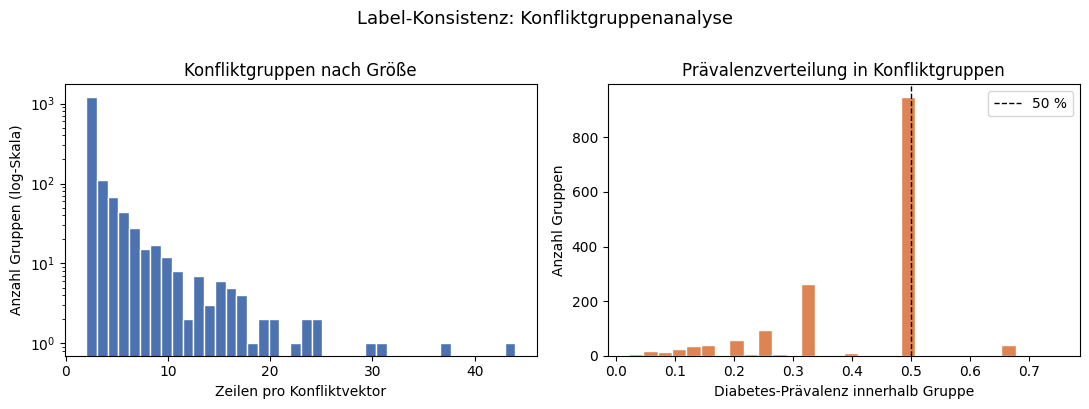

In [23]:
# Distribution of conflict group sizes (how many rows share the same conflicting vector)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: histogram of conflict-group sizes
axes[0].hist(conflict_groups["count"], bins=40, color="#4C72B0", edgecolor="white", log=True)
axes[0].set_xlabel("Zeilen pro Konfliktvektor")
axes[0].set_ylabel("Anzahl Gruppen (log-Skala)")
axes[0].set_title("Konfliktgruppen nach Größe")

# Right: distribution of Diabetes prevalence within conflict groups
axes[1].hist(conflict_groups["mean"], bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, label="50 %")
axes[1].set_xlabel("Diabetes-Prävalenz innerhalb Gruppe")
axes[1].set_ylabel("Anzahl Gruppen")
axes[1].set_title("Prävalenzverteilung in Konfliktgruppen")
axes[1].legend()

plt.suptitle("Label-Konsistenz: Konfliktgruppenanalyse", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

**Exakte Duplikate** entstehen, wenn Zeilen in allen 22 Spalten (Features *und* Target) übereinstimmen. Bei telefonischen Surveys wie BRFSS sind sie unvermeidbar, da viele Befragte dieselbe Kombination von Merkmalsausprägungen aufweisen; sie sind kein Hinweis auf Datenbankfehler und werden *nicht* entfernt.

**Labelsinkonsistenzen** — gleicher Feature-Vektor, widersprüchliches Label — sind methodisch bedeutsamer. Da BRFSS `Diabetes_binary` über Selbstauskunft (ärztliche Mitteilung) erfasst, kann dieselbe Merkmalskombination sowohl von einer Person mit als auch ohne Diagnose genannt werden. Die 21 erfassten Features decken den relevanten Merkmalsraum nicht vollständig ab; unmessbare Prädiktoren (genetische Disposition, Laborwerte, zeitlicher Diagnoseverlauf) sorgen dafür, dass manche Vektoren nicht eindeutig einem Label zuordenbar sind.

Das aus den Konfliktgruppen geschätzte **irreduzible Rauschen** gibt an, wie viele Zeilen selbst bei einem perfekten Modell falsch klassifiziert werden müssen — es ist eine harte untere Schranke für den Bayes-Fehler unter diesem Feature-Set. Dieser Wert entspricht dem, was in `notebooks/01_business_understanding.ipynb`, Section 4, konzeptuell hergeleitet wurde, nun aber empirisch beziffert ist.

Für die Modellierung bedeutet das: Recall-Constraints (z. B. Recall ≥ 0,80) müssen mit Blick auf diese Rauschrate kalibriert werden. Ein Modell, das auf Recall ≥ 0,80 optimiert ist, kann in Konfliktregionen des Feature-Raums strukturell nicht besser werden.

### Interpretation: Label-Konsistenz-Analyse

Die Konfliktgruppen sind fast ausnahmslos klein (2–3 Zeilen), was auf zufälliges Rauschen
hinweist, nicht auf systematische Kodierungsfehler. Der dominante Peak bei einer
Gruppen-Prävalenz von 0,5 (ca. 900 Gruppen) zeigt, dass die Mehrzahl der Konflikte
einfache Paare sind: ein identischer Feature-Vektor erhält einmal Label 0 und einmal Label 1.

Die Verteilung ist asymmetrisch: Gruppen mit Prävalenz < 0,5 überwiegen gegenüber solchen > 0,5. Das heißt, in Konfliktfällen tendiert das Label zur 0 (kein Diabetes). Das stützt die
Hypothese aus dem Business Understanding — nicht diagnostizierte oder nicht gemeldete
Diabetes-Fälle werden als negativ kodiert (FN-Bias), nicht umgekehrt.

Das empirisch geschätzte irreduzible Rauschen (~0,65 % der Zeilen) bildet die untere
Fehlergrenze des Datensatzes. Kein Modell kann diese Fälle korrekt auflösen, da die
Fehlinformation bereits in den Labels steckt. Diese Zahl wird in Phase 5 (Evaluation)
als Interpretationshilfe herangezogen.